# 06 — Por que o dinheiro não volta

**Objetivo:** responder a terceira pergunta do projeto — entre os casos em que
o dinheiro não volta, quais são os motivos e qual pesa mais — e ver se essa
composição mudou ao longo do tempo.

Faz parte da [etapa 8](../README.md#progresso) do projeto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
import urllib.request

sys.path.insert(0, "..")
if not os.path.exists("../visual.py"):  # fora do repositorio (ex: Colab): baixa o padrao visual
    urllib.request.urlretrieve("https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/visual.py", "visual.py")
from visual import grafico, salvar, AZUL, LARANJA, VERDE

URL = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados/fraude.csv"
df = pd.read_csv(URL)
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)
df.shape

(52, 25)

## Antes da composição: composição *de quê*?

O dicionário de dados (`DICIONARIO.md`) tinha uma pergunta em aberto desde a
etapa 2: os três motivos de não devolução somados não batem com
`ValorPixresidualnaodevolvido`. No período inteiro, os motivos somam ~R$ 16 bi
e o residual só ~R$ 6 bi — então os motivos **não** são a decomposição do
residual. Antes de calcular percentual de qualquer coisa, preciso saber qual é
o total.

Hipótese testada: o valor aceito se divide em quatro destinos — o que voltou
inteiro, o que voltou em parte, o que sobrou sem voltar desses casos parciais,
e os casos em que nada voltou (separados por motivo).

In [2]:
devolvido = df["ValorPixdevolvidosintegralmente"] + df["ValorPixdevolvidosparcialmente"]
motivos = (
    df["ValorPixnaodevolvidossaldoinsuficiente"]
    + df["Valornaodevolvidoscontaencerrada"]
    + df["ValorPixnaodevolvidosmotivosdiversos"]
)
residual = df["ValorPixresidualnaodevolvido"]

erro = df["ValorPixcontestadosaceitos"] - (devolvido + residual + motivos)
print(f"erro maximo: R$ {erro.abs().max():,.2f} em {len(df)} meses")

erro maximo: R$ 0.00 em 52 meses


**Fecha exatamente, nos 52 meses:**

```
valor contestado aceito = devolvido integral + devolvido parcial
                        + residual não devolvido
                        + saldo insuficiente + conta encerrada + motivos diversos
```

Leitura: o **residual** é o pedaço que não voltou dos casos devolvidos só em
parte (por isso ele não tem motivo associado); os **três motivos** são os
casos em que nada voltou.

Isso importa pra qualquer número que eu der daqui pra frente. "Saldo
insuficiente" representa **85,8%** do valor dos casos em que nada voltou — mas
só **61,7%** de todo o valor que não voltou, se o residual dos parciais entra
no denominador. Os dois números são verdadeiros; dizer um sem o denominador é
o mesmo tipo de simplificação que a etapa 3 achou na imprensa ("solicitado"
vs "aceito").

Daqui em diante, a composição é **entre os três motivos** — os casos em que
nada voltou —, que é o que a tabela permite explicar por motivo.

## Formato longo

As três colunas de motivo viram linhas (`melt`): uma linha por mês e motivo.
Nesse formato, somar por mês e dividir vira uma operação só.

In [3]:
colunas_motivo = {
    "ValorPixnaodevolvidossaldoinsuficiente": "Saldo insuficiente",
    "Valornaodevolvidoscontaencerrada": "Conta encerrada",
    "ValorPixnaodevolvidosmotivosdiversos": "Motivos diversos",
}

longo = df.melt(
    id_vars=["AnoMes", "Data"],
    value_vars=list(colunas_motivo),
    var_name="coluna",
    value_name="valor",
)
longo["motivo"] = longo["coluna"].map(colunas_motivo)
longo["percentual"] = longo["valor"] / longo.groupby("AnoMes")["valor"].transform("sum") * 100
longo.head(6)

,AnoMes,Data,coluna,valor,motivo,percentual
0,202201,2022-01-01,ValorPixnaodevolvidossaldoinsuficiente,6.207817e+07,Saldo insuficiente,72.668030
1,202202,2022-02-01,ValorPixnaodevolvidossaldoinsuficiente,6.418356e+07,Saldo insuficiente,70.243320
2,202203,2022-03-01,ValorPixnaodevolvidossaldoinsuficiente,1.027211e+08,Saldo insuficiente,70.098601
3,202204,2022-04-01,ValorPixnaodevolvidossaldoinsuficiente,8.068369e+07,Saldo insuficiente,61.810125
4,202205,2022-05-01,ValorPixnaodevolvidossaldoinsuficiente,9.549533e+07,Saldo insuficiente,58.050481
5,202206,2022-06-01,ValorPixnaodevolvidossaldoinsuficiente,1.064158e+08,Saldo insuficiente,69.788094


## Composição mês a mês

Barras empilhadas em **percentual** do total dos três motivos, não em reais —
o volume de contestações triplicou em out/2025 (etapa 5), e em valor absoluto
essa quebra esconderia qualquer mudança de composição.

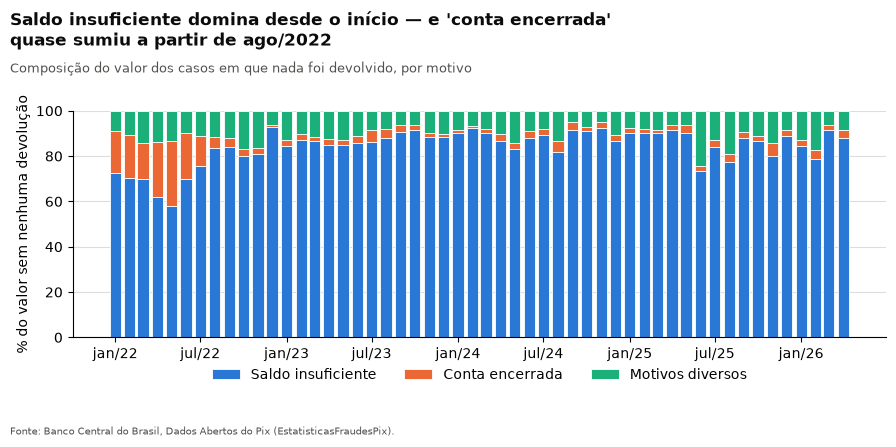

In [4]:
cores = {"Saldo insuficiente": AZUL, "Conta encerrada": LARANJA, "Motivos diversos": VERDE}
tabela = longo.pivot(index="Data", columns="motivo", values="percentual")[list(cores)]

fig, ax = grafico(
    "Saldo insuficiente domina desde o início — e 'conta encerrada'\nquase sumiu a partir de ago/2022",
    subtitulo="Composição do valor dos casos em que nada foi devolvido, por motivo",
)
base = pd.Series(0.0, index=tabela.index)
for motivo, cor in cores.items():
    ax.bar(tabela.index, tabela[motivo], bottom=base, width=24, color=cor,
           edgecolor="white", linewidth=0.6, label=motivo)
    base += tabela[motivo]

ax.set_ylim(0, 100)
ax.set_ylabel("% do valor sem nenhuma devolução")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)

salvar(fig, "06-motivos-nao-devolucao.png")
plt.show()

## A composição mudou?

Começo contra fim da série (12 meses de cada lado), e o corte que o gráfico
sugere (jul/2022 → ago/2022).

In [5]:
def composicao(parte):
    soma = parte.groupby("motivo")["valor"].sum()
    return (soma / soma.sum() * 100).round(1)

inicio = longo[longo["AnoMes"] <= 202212]
fim = longo[longo["AnoMes"] >= 202505]
comparacao = pd.DataFrame({"jan–dez/2022": composicao(inicio), "mai/2025–abr/2026": composicao(fim)})
comparacao.loc[list(cores)]

,jan–dez/2022,mai/2025–abr/2026
motivo,,
Saldo insuficiente,79.5,83.9
Conta encerrada,9.8,3.2
Motivos diversos,10.8,12.9


In [6]:
encerrada = longo[longo["motivo"] == "Conta encerrada"]
antes = encerrada[encerrada["AnoMes"] <= 202207]["percentual"]
depois = encerrada[encerrada["AnoMes"] >= 202208]["percentual"]
print(f"conta encerrada, jan-jul/2022:        de {antes.min():.1f}% a {antes.max():.1f}%")
print(f"conta encerrada, ago/2022 em diante:  de {depois.min():.1f}% a {depois.max():.1f}% (media {depois.mean():.1f}%)")

conta encerrada, jan-jul/2022:        de 13.5% a 28.7%
conta encerrada, ago/2022 em diante:  de 0.9% a 5.6% (media 2.8%)


## O achado

- **Saldo insuficiente é o motivo dominante, e não por pouco:** 85,8% do valor
  dos casos em que nada voltou, no período inteiro. Quando o dinheiro não
  volta, na grande maioria das vezes é porque a conta que recebeu o golpe já
  foi esvaziada quando o bloqueio chega.
- **A composição mudou uma vez, e de forma nítida, em ago/2022.** "Conta
  encerrada" ia de 13,5% a 28,7% nos meses de jan–jul/2022 e, a partir de
  ago/2022, nunca passou de 5,6% (média 2,8%). Não há sobreposição entre os
  dois períodos. O espaço foi ocupado por saldo insuficiente.
- **Depois disso, a composição é estável.** Comparando 2022 com os últimos 12
  meses, saldo insuficiente vai de 79,5% para 83,9%; a maior parte dessa
  diferença é o efeito de ago/2022, não uma tendência contínua. A quebra de
  volume de out/2025 (etapa 5) não alterou a composição.

**O que isto não mostra:**

- **Por que** "conta encerrada" despencou em ago/2022. Não pesquisei mudança
  de regra nessa data — fica como pergunta aberta, do mesmo tipo que a etapa 6
  respondeu pra out/2025.
- O que exatamente entra em **"motivos diversos"** (~10% do valor). A
  documentação da API não detalha.
- A composição do **residual** dos casos parciais, que não tem motivo
  associado na tabela.